## Regular water waves interacting with a semi-circular obtacle - Frequency-Domain BEM

**3D Boundary Element Method for Linear Wave Propagation**

This tutorial presents the implementation of a 3D BEM to simulate the propagation of regular linear water waves interacting with a semi-circular obstacle in a single domain.

The formulation is based on:
- Linear potential flow theory  
- Frequency-domain (time-harmonic) analysis  
- Boundary integral equation formulation  

Objectives of this notebook:
- Introduce the workflow and structure of the code  
- Solve the wave structure interaction problem  
- Compute wave reflection and transmission coefficients
- Compute the force components

**1. Environment setup**

In [1]:
# 1. Automatic reloading of your .py files
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath(".."))    

from MESH.SEMI_CIRCULAR import SEMI_CIRCULAR

import meshio
import numpy as np

from BEM_UTILS.constants import gravity, rho

from BEM_UTILS.PROCESS_MESH import PROCESS_MESH
from BEM_UTILS.PROCESS_CONNECTIVITY import PROCESS_CONNECTIVITY
from BEM_UTILS.IDENTIFY_BOUNDARY_ELEMENTS import IDENTIFY_BOUNDARY_ELEMENTS
from BEM_UTILS.COS_DIR import COS_DIR
from BEM_UTILS.MATCHING import MATCHING

from MATRICES.GHMAT6 import GHMAT6
from MATRICES.ETAXJA import ETAXJA
from MATRICES.EXTIN6 import EXTIN6
from MATRICES.LOCIN6 import LOCIN6
from MATRICES.TRILOC6 import TRILOC6
from MATRICES.FUNDA6 import FUNDA6

from BOUNDARY_CONDITIONS.BC_FREE_SURFACE import BC_FREE_SURFACE
from BOUNDARY_CONDITIONS.BC_FAR_FIELD_IN import BC_FAR_FIELD_IN
from BOUNDARY_CONDITIONS.BC_FAR_FIELD_OUT import BC_FAR_FIELD_OUT
from BOUNDARY_CONDITIONS.BC_SCATTERING import BC_SCATTERING

from BEM_UTILS.FORCE import FORCE

from BEM_UTILS.FX_FUNCTION import FX_FUNCTION
from BEM_UTILS.ENERGY_FLUX import ENERGY_FLUX
from BEM_UTILS.NODES_FS import NODES_FS
from BEM_UTILS.INTERNAL_POINTS import INTERNAL_POINTS

from BEM_UTILS.VISUAL_FREE_SURFACE import VISUAL_FREE_SURFACE

from BOUNDARY_CONDITIONS.FLUXES_FREE_SURFACE import FLUXES_FREE_SURFACE
from BOUNDARY_CONDITIONS.FLUXES_FAR_FIELD_IN import FLUXES_FAR_FIELD_IN
from BOUNDARY_CONDITIONS.FLUXES_FAR_FIELD_OUT import FLUXES_FAR_FIELD_OUT

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # activates 3D plotting

**2.1 Physical domain and geometry parameters**

In [2]:
# FLUID DOMAIN
DEPTH         = 0.50;
WIDTH_CHANNEL = 0.25*DEPTH;
LX = 3.00*DEPTH;

# Structure geometry
RADIUS        = 0.45;
N_STRUCT = 1;

# Numerical model
NUM_OF_REG = 1;

**2.2 Mesh generation**

In [3]:
# GMSH mesh
SEMI_CIRCULAR(DEPTH,RADIUS,WIDTH_CHANNEL,LX)

**2.3 Wave parameters and frequency range**

In [4]:
# Number of frequencies / wave cases
ttmax = 15

# Dimensionless wavenumber (k*h)
kh = np.linspace(0.005, 3.00, ttmax)

# Wave steepness H/λ
HL = 0.01

**3. Mesh**

In [5]:
# Read the Gmsh file and extract node coordinates and element connectivity
MESH_0_POS, MESH_0_QUADS9 = PROCESS_MESH("SEMI_CIRCULAR.msh")

In [6]:
# Quadrilateral elements are used; each element has 9 nodes ordered counterclockwise.
NCONEC = 9;

In [7]:
# Initialize arrays to store the number of nodes (N) and elements (NE) per region
N  = [0] * NUM_OF_REG
NE = [0] * NUM_OF_REG

In [8]:
# Extract the number of nodes, number of elements, and reorder element connectivity
# to match the node orientation required by the BEM formulation
N[0] ,  NE[0] ,  KCONEC_0 = PROCESS_CONNECTIVITY(MESH_0_POS , MESH_0_QUADS9)

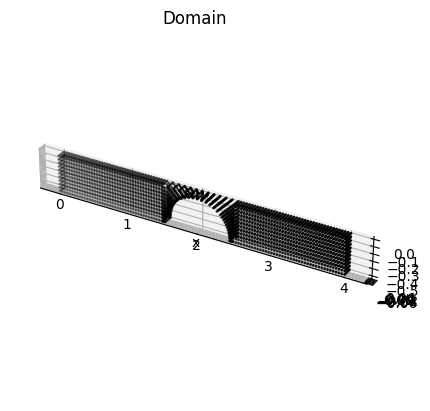

In [9]:
# Domain visulization
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    MESH_0_POS[:,0],
    MESH_0_POS[:,1],
    MESH_0_POS[:,2],
    c='k',
    s=1
)

# DOMAIN LIMITS
x_min, x_max = np.min(MESH_0_POS[:,0]), np.max(MESH_0_POS[:,0])
y_min, y_max = np.min(MESH_0_POS[:,1]), np.max(MESH_0_POS[:,1])
z_min, z_max = np.min(MESH_0_POS[:,2]), np.max(MESH_0_POS[:,2])

Lx = x_max - x_min
Ly = y_max - y_min
Lz = z_max - z_min

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Domain")

# Aspect ratio
ax.set_box_aspect([Lx, Ly, Lz])

plt.show()

In [10]:
# Identify elements belonging to each boundary and compute their outward normal vectors
REF_R0 , NORMAL_0 = IDENTIFY_BOUNDARY_ELEMENTS(NCONEC , KCONEC_0 , MESH_0_POS , NE[0], N_STRUCT)

**4. Influence matrices**

In [11]:
# Form H and B matrices
H , G = GHMAT6(MESH_0_POS , NCONEC , KCONEC_0 , NE[0] , N[0] , DEPTH);

**5. Frequency loop and boundary condition application**

In [12]:
# Preallocate arrays for reflection/transmission coefficients
CR = np.zeros(ttmax)
CT = np.zeros(ttmax)
KR = np.zeros(ttmax)
KT = np.zeros(ttmax)

# Preallocate arrays for force components
FX = np.zeros(ttmax,dtype=complex)
FY = np.zeros(ttmax,dtype=complex)
FZ = np.zeros(ttmax,dtype=complex)

# Dictionary to store wave properties for each frequency case
WAVE = {
    "k": np.zeros(ttmax),
    "lambda": np.zeros(ttmax),
    "HL": np.zeros(ttmax),
    "T": np.zeros(ttmax),
    "omega": np.zeros(ttmax),
    "Amp": np.zeros(ttmax)
}

# Frequency loop
for tt in range(ttmax):

    print(tt + 1)

    # Compute wavenumber from dimensionless kh
    k = kh[tt] / DEPTH

    # Linear wave dispersion relation → wave period
    T = np.sqrt((2*np.pi)**2 / (k * gravity * np.tanh(k * DEPTH)))

    # Wave frequency and angular frequency
    f = 1.0 / T
    omega = 2*np.pi*f

    # Wave height from steepness H/λ and corresponding amplitude
    Wave_height = HL * (2*np.pi / k)
    Amp = Wave_height / 2

    # Store wave properties
    WAVE["k"][tt] = k
    WAVE["lambda"][tt] = 2*np.pi / k
    WAVE["HL"][tt] = Wave_height / (2*np.pi / k)
    WAVE["T"][tt] = T
    WAVE["omega"][tt] = omega
    WAVE["Amp"][tt] = Amp

    # Backup original system matrices before applying BCs
    A = H.copy()
    B = G.copy()

    # ------------------------
    # Apply boundary conditions
    # ------------------------

    # Free-surface boundary condition
    A = BC_FREE_SURFACE(A, B, omega, gravity, NCONEC, REF_R0["FS"], KCONEC_0, NE, 0)

    # Radiation boundary conditions at inlet and outlet (far field)
    A = BC_FAR_FIELD_IN(A, B, k, NCONEC, NORMAL_0,  REF_R0["IN"],  KCONEC_0, NE, 0)
    A = BC_FAR_FIELD_OUT(A, B, k, NCONEC, NORMAL_0, REF_R0["OUT"], KCONEC_0, NE, 0)

    # Scattering boundary condition from incident potential at inlet
    BC_S = np.zeros_like(KCONEC_0[:NCONEC, :], dtype=np.complex128)
    BC_S = BC_SCATTERING(BC_S, Wave_height, k, omega, gravity, DEPTH, MESH_0_POS, NCONEC, REF_R0["IN"], KCONEC_0, N, NE, 0)

    # Build right-hand-side vector (B · BC_S)
    FX_S = FX_FUNCTION(NCONEC, B, BC_S, N, NE)

    # Solve linear BEM system
    Coef_S = np.linalg.solve(A, FX_S)

    # Incident wave energy flux  
    FI = (WIDTH_CHANNEL) * (1/8) * rho * gravity * (Wave_height**2) * (omega / k) * (
        0.5 * (1 + (2 * k * DEPTH) / np.sinh(2 * k * DEPTH))
     )

    # Compute reflected and transmitted energy fluxes
    FLUX_REFLE, FLUX_TRANS = ENERGY_FLUX(Coef_S, omega, rho, k, gravity, Wave_height, DEPTH, NCONEC,
        REF_R0["IN"],  MESH_0_POS,
        REF_R0["OUT"], MESH_0_POS,
        KCONEC_0,
        N, NE, 0, 0)

    # Reflection and transmission coefficients (amplitude-based)
    CR[tt] = np.sqrt(FLUX_REFLE / FI)
    CT[tt] = np.sqrt(FLUX_TRANS / FI)

    # Reflection, transmission and dissipation coefficients (energy-based)
    KR[tt] = FLUX_REFLE / FI
    KT[tt] = FLUX_TRANS / FI

    # Force components
    FX[tt], FY[tt], FZ[tt] = FORCE(Coef_S, MESH_0_POS, NCONEC, REF_R0["IMPERMEABLE"], KCONEC_0, N, NE, 0) 

# END LOOPS

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15


**6. Results**

**6.1 Energy coeffcients**

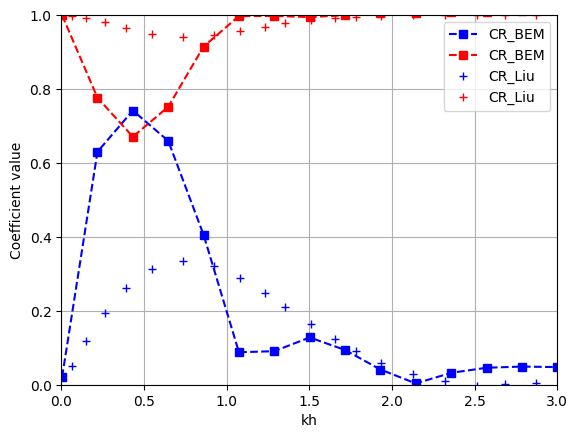

In [13]:
# DATA from: Analysis of wave interaction with submerged perforated semi-circular breakwaters through multipole method Yong Liu, Hua-Jun Li

kh_Liu = np.array([
0.064, 0.152, 0.263, 0.391, 0.546,
0.734, 0.925, 1.083, 1.234, 1.356,
1.511, 1.654, 1.780, 1.934, 2.126,
2.321, 2.512, 2.685, 2.869
])

CR_Liu = np.array([
0.051, 0.118, 0.194, 0.262, 0.314,
0.336, 0.320, 0.288, 0.247, 0.210,
0.163, 0.123, 0.092, 0.060, 0.030,
0.009, -0.004, 0.003, 0.006
])

CT_Liu = np.sqrt(1 - CR_Liu**2)

# Plot of the CR and CT vs kh
plt.figure(1)

plt.plot(kh, CR, 'b--s', label='CR_BEM')
plt.plot(kh, CT, 'r--s', label='CR_BEM')

plt.plot(kh_Liu, CR_Liu, 'b+', label='CR_Liu')
plt.plot(kh_Liu, CT_Liu, 'r+', label='CR_Liu')

plt.xlim([0, 3.00])
plt.ylim([0, 1.00])

plt.xlabel('kh')
plt.ylabel('Coefficient value')

plt.legend()
plt.grid(True)

plt.savefig("CR_CT.pdf")

plt.show()

**6.2 Force components**

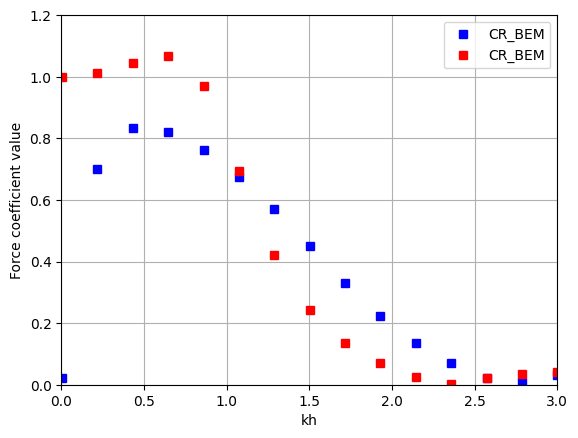

In [24]:
# DATA from: Analysis of wave interaction with submerged perforated semi-circular breakwaters through multipole method Yong Liu, Hua-Jun Li

plt.figure(100)

TERM = (rho*gravity*2*WAVE["Amp"]*RADIUS*WIDTH_CHANNEL)

CFX = np.abs(1j*rho*WAVE["omega"]*FX)/TERM
CFZ = np.abs(1j*rho*WAVE["omega"]*FZ)/TERM

plt.plot(kh, CFX, 'bs', label='CR_BEM')
plt.plot(kh, CFZ, 'rs', label='CR_BEM')

plt.xlim([0, 3.00])
plt.ylim([0, 1.20])

plt.xlabel('kh')
plt.ylabel('Force coefficient value')

plt.legend()
plt.grid(True)

plt.savefig("FX_FY_FZ.pdf")

plt.show()

**6.3 Free surface**

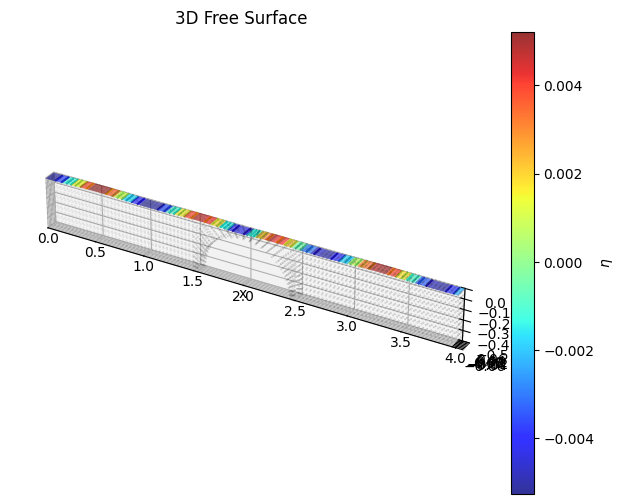

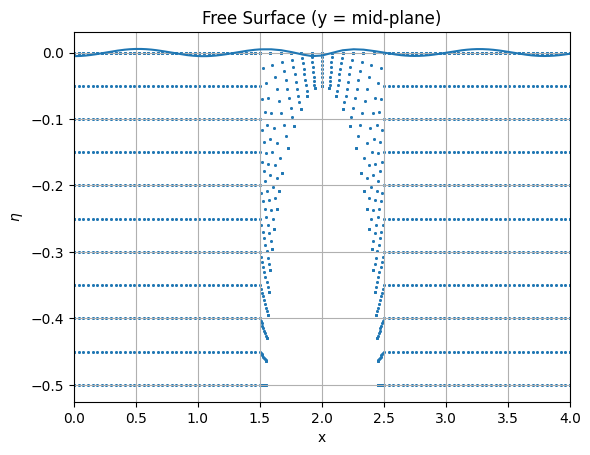

In [15]:
# Free surface plot
PHI_FS = VISUAL_FREE_SURFACE(Coef_S, k, omega, gravity, Wave_height, DEPTH, NCONEC, REF_R0["FS"], MESH_0_POS, MESH_0_POS, KCONEC_0, N, NE, 0)

**6.4 Internal points**

In [16]:
# Initialize array to store flux values (dphi/dn) across all boundaries
Fluxes_S = np.zeros_like(KCONEC_0[0:NCONEC,:], dtype=np.complex128)

In [17]:
# For single domain cases Coef_S contains only velocity potentials

# Boundary conditions
# Inlet  dPHI/dn + ik PHI = 0
# Outlet dPHI/dn - ik PHI = 0
# FS     dPHI/dn - omega^2/g PHI = 0
# Bottom dPHI/dn = 0
# Imper  dPHI/dn = 0
# Front  dPHI/dn = 0
# Back   dPHI/dn = 0

# Fluxes calculation
Fluxes_S = FLUXES_FREE_SURFACE(Coef_S, Fluxes_S, omega, gravity, NCONEC, REF_R0["FS"], KCONEC_0, N, NE, 0)
Fluxes_S = FLUXES_FAR_FIELD_IN( Coef_S, Fluxes_S, k, NCONEC, NORMAL_0, REF_R0["IN"],  KCONEC_0, N, NE, 0)
Fluxes_S = FLUXES_FAR_FIELD_OUT(Coef_S, Fluxes_S, k, NCONEC, NORMAL_0, REF_R0["OUT"], KCONEC_0, N, NE, 0)

In [22]:
# Calculation of internal velocity potentials
Max_X = max(MESH_0_POS[:,0])

dx = 0.01
dz = 0.05

CX = np.linspace(0 + dx, Max_X - dx, 301)
CY = np.zeros_like(CX)
CZ = np.zeros_like(CX) - dz

DSOL = INTERNAL_POINTS(Coef_S, Fluxes_S, DEPTH, CX, CY, CZ, MESH_0_POS, NCONEC, KCONEC_0, N, NE, 0)

ETA_IP = np.real((1j * rho * omega) * DSOL  * np.exp(-1j * omega * np.pi / omega))

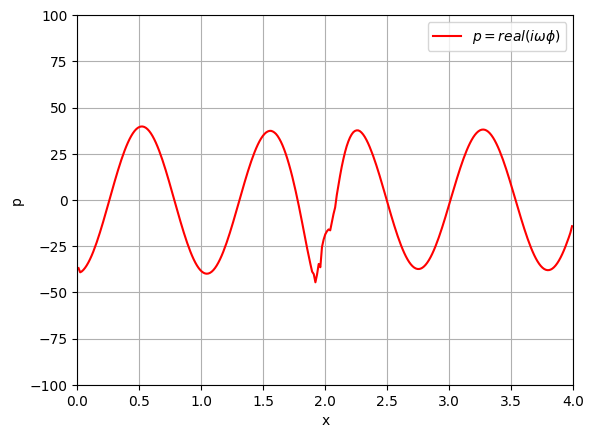

In [23]:
# Plot of the dynamic pressure amplitude
plt.figure()

plt.plot(CX, ETA_IP, 'r-', label=r'$p = real(i\omega\phi)$')

plt.xlim([0, Max_X])
plt.ylim([-100, 100])

plt.xlabel('x')
plt.ylabel('p')

plt.legend()
plt.grid(True)

# Optional: display the plot
plt.show()